In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


In [62]:
PATH = "../data/raw/tb_lobby_stats_player.csv"
df = pd.read_csv(PATH)

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 184152 entries, 0 to 184151
Data columns (total 38 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   idLobbyGame     184152 non-null  int64  
 1   idPlayer        184152 non-null  int64  
 2   idRoom          184152 non-null  int64  
 3   qtKill          184152 non-null  int64  
 4   qtAssist        184152 non-null  int64  
 5   qtDeath         184152 non-null  int64  
 6   qtHs            184152 non-null  int64  
 7   qtBombeDefuse   184152 non-null  int64  
 8   qtBombePlant    184152 non-null  int64  
 9   qtTk            184032 non-null  float64
 10  qtTkAssist      184032 non-null  float64
 11  qt1Kill         184152 non-null  int64  
 12  qt2Kill         184152 non-null  int64  
 13  qt3Kill         184152 non-null  int64  
 14  qt4Kill         184152 non-null  int64  
 15  qt5Kill         184152 non-null  int64  
 16  qtPlusKill      184152 non-null  int64  
 17  qtFirstKill     18415

### Perguntas de Negócio
- 1 -> quantidade de jogadores
- 2 -> quantidade de partidas
- 3 -> quantidade de partidas por jogador 
- 4 -> quantidade de kills por jogador nas partidas que ele participou
- 5 -> qual max e min de kills

In [64]:
# 1 - 
qtd_jogadores = df['idPlayer'].nunique()
id_max_player = df['idPlayer'].max()
id_min_player = df['idPlayer'].min()
print(f"Quantidade de jogadores únicos: {qtd_jogadores}")
print(f"id max: {id_max_player}")
print(f"id max: {id_min_player}")
#print(f"ids_faltando: {id_max_player - qtd_jogadores}")

Quantidade de jogadores únicos: 2469
id max: 2716
id max: 1


In [65]:
# 2 - 
qtd_partidas = df['idLobbyGame'].nunique()
id_max_partida = df['idLobbyGame'].max()
id_min_partida = df['idLobbyGame'].min()

print(f"Quantidade de partidas únicas: {qtd_partidas}")
print(f"id max: {id_max_partida}")
print(f"id min: {id_min_partida}")

Quantidade de partidas únicas: 172911
id max: 172911
id min: 1


Verificando a relação entre jogadores e partidas

In [66]:
# Agrupando partidas e jogadores
partidas_por_jogador = (
    df.groupby('idPlayer')['idLobbyGame']
    .nunique()
    .reset_index(name='qtdPartidas')
    .sort_values(by='qtdPartidas', ascending=False)
)

print(partidas_por_jogador['qtdPartidas'].describe())

count    2469.000000
mean       74.585662
std        98.617952
min         1.000000
25%         8.000000
50%        34.000000
75%       104.000000
max       873.000000
Name: qtdPartidas, dtype: float64


In [67]:
# Verificando faixas de partidas específicas 
print("Jogadores com 1 partida:",
      (partidas_por_jogador['qtdPartidas'] == 1).sum())

print("Jogadores com até 5 partidas:",
      (partidas_por_jogador['qtdPartidas'] <= 5).sum())

print("Jogadores com até 10 partidas:",
      (partidas_por_jogador['qtdPartidas'] <= 10).sum())

print("Jogadores com até 20 partidas:",
      (partidas_por_jogador['qtdPartidas'] <= 20).sum())

print("Jogadores com mais de 100 partidas:",
      (partidas_por_jogador['qtdPartidas'] > 100).sum())

Jogadores com 1 partida: 129
Jogadores com até 5 partidas: 456
Jogadores com até 10 partidas: 695
Jogadores com até 20 partidas: 971
Jogadores com mais de 100 partidas: 639


In [68]:
# Criando df de resumo paras as faixas acumuladas analisadas 
resumo_partidas = pd.DataFrame({
    'Faixa de partidas': [
        '1 partida',
        'Até 5 partidas',
        'Até 10 partidas',
        'Até 20 partidas',
        'Mais de 100 partidas'
    ],
    'Quantidade de jogadores': [
        (partidas_por_jogador['qtdPartidas'] == 1).sum(),
        (partidas_por_jogador['qtdPartidas'] <= 5).sum(),
        (partidas_por_jogador['qtdPartidas'] <= 10).sum(),
        (partidas_por_jogador['qtdPartidas'] <= 20).sum(),
        (partidas_por_jogador['qtdPartidas'] > 100).sum()
    ]
})

total_jogadores = len(partidas_por_jogador)

resumo_partidas['Porcentagem (%)'] = (
    resumo_partidas['Quantidade de jogadores']
    / total_jogadores
    * 100
).round(2)

display(resumo_partidas)

,Faixa de partidas,Quantidade de jogadores,Porcentagem (%)
0,1 partida,129,5.22
1,Até 5 partidas,456,18.47
2,Até 10 partidas,695,28.15
3,Até 20 partidas,971,39.33
4,Mais de 100 partidas,639,25.88


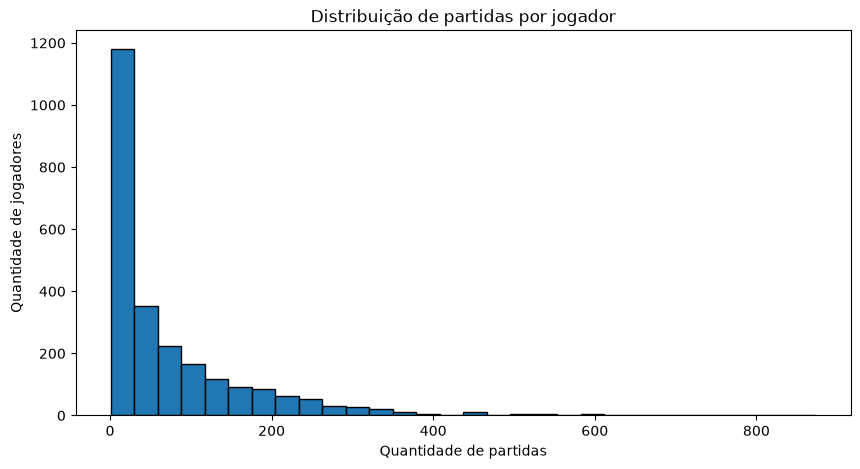

In [69]:
# Plotando a distribuição de partidas por jogador
plt.figure(figsize=(10, 5))

plt.hist(
    partidas_por_jogador['qtdPartidas'],
    bins=30,
    edgecolor='black'
)

plt.xlabel('Quantidade de partidas')
plt.ylabel('Quantidade de jogadores')
plt.title('Distribuição de partidas por jogador')

plt.show()

In [70]:
# Categorizando jogadores por faixas não acumuladas
faixas = pd.cut(
    partidas_por_jogador['qtdPartidas'],
    bins=[0, 1, 5, 10, 20, 50, 100, 200, float('inf')],
    labels=[
        '1',
        '2-5',
        '6-10',
        '11-20',
        '21-50',
        '51-100',
        '101-200',
        '201+'
    ]
)

jogadores_por_faixa = (
    faixas.value_counts()
    .sort_index()
)

print(jogadores_por_faixa)

qtdPartidas
1          129
2-5        327
6-10       239
11-20      276
21-50      473
51-100     386
101-200    377
201+       262
Name: count, dtype: int64


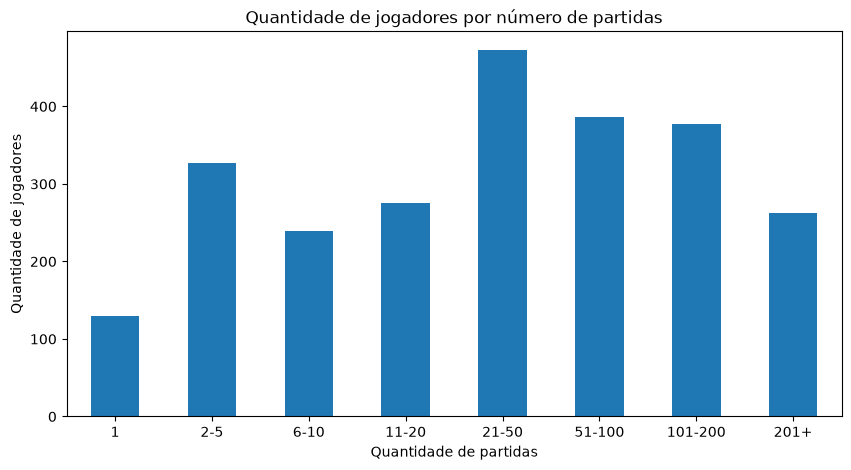

In [71]:
# Plotando as categorias de faixas em um gráfico de barras
plt.figure(figsize=(10, 5))

jogadores_por_faixa.plot(kind='bar')

plt.xlabel('Quantidade de partidas')
plt.ylabel('Quantidade de jogadores')
plt.title('Quantidade de jogadores por número de partidas')

plt.xticks(rotation=0)

plt.show()

Analisando separadamente os jogadores que tem mais de 200 partidas

In [72]:
# Filtrando os jogadores com mais de 200 partidas
jogadores_201_mais = partidas_por_jogador[
    partidas_por_jogador['qtdPartidas'] > 200
].copy() # Evito alterar partidas por jogador

display(jogadores_201_mais)

,idPlayer,qtdPartidas
1745,1922,873
1510,1663,746
2080,2289,677
18,20,666
1210,1335,625
...,...,...
125,138,202
717,785,201
307,342,201
2284,2514,201


In [73]:
jogadores_201_mais['qtdPartidas'].describe()

count    262.000000
mean     301.343511
std      109.181088
min      201.000000
25%      228.250000
50%      263.000000
75%      331.750000
max      873.000000
Name: qtdPartidas, dtype: float64

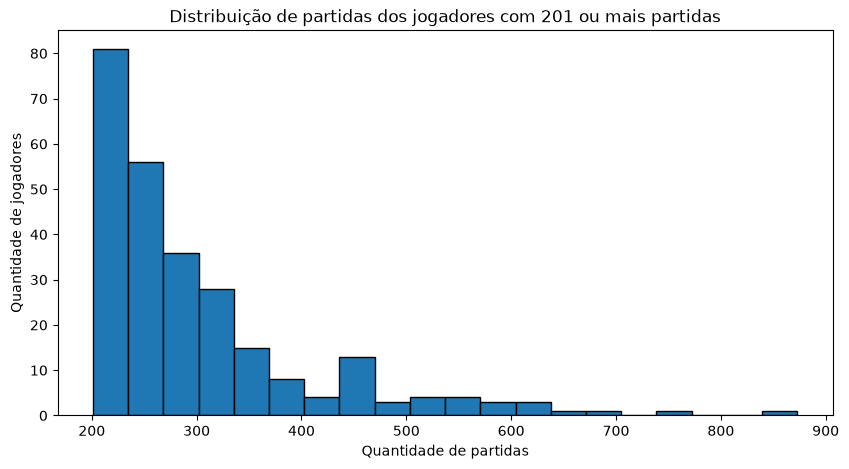

In [74]:
# Plotando a distribuição de partidas por jogadores que jogaram mais de 200 partidas
plt.figure(figsize=(10, 5))

plt.hist(
    jogadores_201_mais['qtdPartidas'],
    bins=20,
    edgecolor='black'
)

plt.xlabel('Quantidade de partidas')
plt.ylabel('Quantidade de jogadores')
plt.title('Distribuição de partidas dos jogadores com 201 ou mais partidas')

plt.show()

In [75]:
# Categorizando os jogadores por faixas não acumuladas
faixas_201 = pd.cut(
    jogadores_201_mais['qtdPartidas'],
    bins=[200, 300, 400, 500, 600, 700, 800, 900],
    labels=[
        '201-300',
        '301-400',
        '401-500',
        '501-600',
        '601-700',
        '701-800',
        '801-900'
    ]
)

distribuicao_201 = (
    faixas_201
    .value_counts()
    .sort_index()
)

display(distribuicao_201)

qtdPartidas
201-300    172
301-400     52
401-500     20
501-600     10
601-700      6
701-800      1
801-900      1
Name: count, dtype: int64

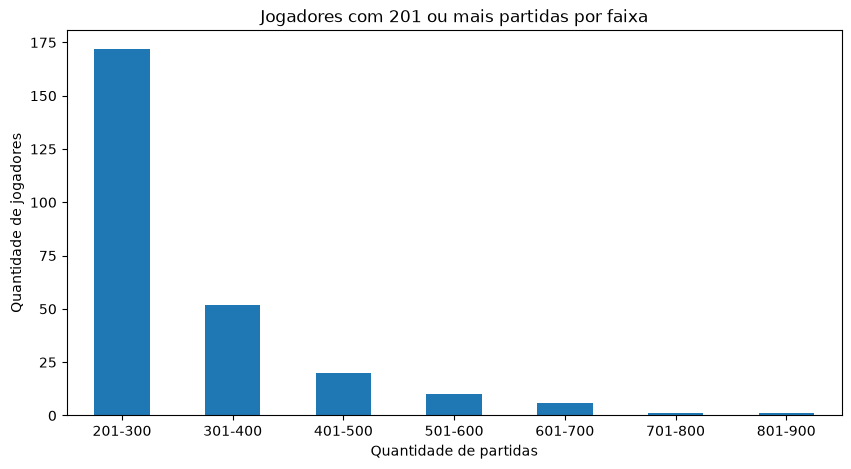

In [76]:
plt.figure(figsize=(10, 5))

distribuicao_201.plot(kind='bar')

plt.xlabel('Quantidade de partidas')
plt.ylabel('Quantidade de jogadores')
plt.title('Jogadores com 201 ou mais partidas por faixa')

plt.xticks(rotation=0)

plt.show()

1) O dataset possui 172.911 partidas únicas e 2.469 jogadores únicos.

2) A quantidade média de partidas por jogador é de aproximadamente 74,59 enquanto a mediana é de 34 partidas. O desvio padrão é de aproximadamente 98,62 partidas. Indicando uma grande dispersão na quantidade de partidas registradas entre os jogadores.

3) A quantidade de partidas por jogador varia de 1 a 873 partidas. Indicando a existência de jogadores com uma quantidade de partidas muito superior aos outros.

4) Aproximadamente 39% dos jogadores possuem até 20 partidas, mostrando que uma parcela considerável dos jogadores apresenta um histórico relativamente pequeno no dataset.

5) Aproximadamente 26% dos jogadores possuem mais de 100 partidas.

6) Considerando as faixas analisadas (1, 2–5, 6–10, 11–20, 21–50, 51–100, 101–200 e 201+), a faixa com maior número de jogadores é a de 21 a 50 partidas, contendo 473 jogadores.

7) Foram identificados 262 jogadores com 201 ou mais partidas,aproximadamente 10,6% dos 2.469 jogadores.

8) Entre esses 262 jogadores, a média é de aproximadamente 301,34 partidas a mediana é de 263 partidas e o desvio-padrão é de aproximadamente 109,18 partidas, mostrando que ainda existe uma dispersão considerável na quantidade de partidas mesmo dentro desse grupo.

9) Entre os jogadores com 201 ou mais partidas, 172 dos 262 aproximadamente 65,6% possuem entre 201 e 300 partidas, existe uma forte concentração próxima ao limite inferior analisado.

In [77]:
# 4 - 
kills_por_partida = (
    df[['idPlayer', 'idLobbyGame', 'qtKill', 'dtCreatedAt']]
    .sort_values(by=['idPlayer', 'dtCreatedAt'])
)


display(kills_por_partida)
#kills_por_partida.style.set_table_attributes('style="display:block; max-height:400px; overflow-y:auto; overflow-x:auto;"')

,idPlayer,idLobbyGame,qtKill,dtCreatedAt
0,1,1,5,2022-01-21 19:45:44
1,1,2,24,2022-02-04 02:09:47
2,2,3,6,2021-09-18 18:07:43
4,2,4,8,2021-09-27 00:17:45
5,2,5,10,2021-09-29 22:05:47
...,...,...,...,...
184147,2716,172907,21,2021-11-27 16:47:57
184148,2716,172908,15,2021-12-10 01:08:48
184149,2716,172909,9,2022-01-09 21:01:10
184150,2716,172910,15,2022-01-14 17:42:37


In [78]:
# 5 - 
max_kill = df['qtKill'].max()
min_kill = df['qtKill'].min()
print(max_kill)
print(min_kill)

85
0


Analisando a relação dos jogadores com mais partidas e as kills

In [79]:
df_jogadores_201_mais = df[
    df['idPlayer'].isin(jogadores_201_mais['idPlayer'])
].copy()

display(
    df_jogadores_201_mais[
        ['idPlayer', 'idLobbyGame', 'qtKill', 'dtCreatedAt']
    ]
    .sort_values(['idPlayer', 'dtCreatedAt'])
)

,idPlayer,idLobbyGame,qtKill,dtCreatedAt
243,10,228,18,2021-09-14 17:09:38
245,10,229,13,2021-09-14 17:50:16
246,10,230,7,2021-09-15 18:16:36
248,10,231,28,2021-09-15 19:02:00
250,10,232,37,2021-09-15 20:36:33
...,...,...,...,...
183410,2699,172170,18,2022-02-10 19:13:07
183411,2699,172171,24,2022-02-10 20:47:02
183412,2699,172172,19,2022-02-10 21:43:36
183413,2699,172173,11,2022-02-10 22:39:10


In [80]:
resumo_jogadores_201 = (
    df_jogadores_201_mais
    .groupby('idPlayer')
    .agg(
        qtdPartidas=('idLobbyGame', 'nunique'),
        totalKills=('qtKill', 'sum'),
        mediaKills=('qtKill', 'mean'),
        medianaKills=('qtKill', 'median'),
        minKills=('qtKill', 'min'),
        maxKills=('qtKill', 'max')
    )
    .reset_index()
    .sort_values('qtdPartidas', ascending=False)
)

display(resumo_jogadores_201)

,idPlayer,qtdPartidas,totalKills,mediaKills,medianaKills,minKills,maxKills
182,1922,873,23926,27.406644,27.0,3,68
158,1663,746,12469,16.714477,16.0,0,39
224,2289,677,13672,20.194978,20.0,0,46
2,20,666,15794,23.714715,24.0,1,49
130,1335,625,12946,20.713600,21.0,0,50
...,...,...,...,...,...,...,...
129,1320,202,3851,19.064356,19.0,2,40
250,2514,201,3158,15.711443,15.0,0,32
37,342,201,4449,22.134328,22.0,2,69
31,316,201,3512,17.472637,17.0,4,34


Verificando duplicatas

In [ ]:
# Verificando se o mesmo jogador aparece mais de uma vez na mesma partida?
jogador_partida_repetidos = df.duplicated(
    subset=['idPlayer', 'idLobbyGame'],
    keep=False
)

print(
    f"Quantidade de linhas com jogador e partida repetidos: "
    f"{jogador_partida_repetidos.sum()}"
)
# -> não, cada linha de um jogador é uma partida distinta

Quantidade de linhas com jogador e partida repetidos: 0


In [82]:
# Verificando se as partidas se repetem
partidas_repetidas = df['idLobbyGame'].value_counts()

display(partidas_repetidas)

idLobbyGame
58891     5
4508      4
17622     4
17777     4
17782     4
         ..
172907    1
172908    1
172909    1
172910    1
172911    1
Name: count, Length: 172911, dtype: int64

In [83]:
# Verificando se a partida 58891 tem 5 jogadores diferentes
lobby_58891 = df[df['idLobbyGame'] == 58891][
    ['idLobbyGame', 'idPlayer']
]

display(lobby_58891)

,idLobbyGame,idPlayer
65278,58891,878
65279,58891,1169
65280,58891,1889
65281,58891,2012
65282,58891,2259


In [84]:
# Quantidade de rooms diferentes em cada lobby
rooms_por_lobby = df.groupby('idLobbyGame')['idRoom'].nunique()

# Seleciona apenas os lobbies que possuem mais de uma room
lobbies_multiplas_rooms = rooms_por_lobby[
    rooms_por_lobby > 1
].index

# Filtra colunas ideais
analise_rooms = (
    df[df['idLobbyGame'].isin(lobbies_multiplas_rooms)][
        [
            'idLobbyGame',
            'idRoom',
            'idPlayer',
            'flWinner',
            'qtRoundsPlayed'
        ]
    ]
    .sort_values(
        by=['idLobbyGame', 'idRoom', 'idPlayer']
    )
)

#display(analise_rooms)
analise_rooms.style.set_table_attributes('style="display:block; max-height:400px; overflow-y:auto; overflow-x:auto;"')

,idLobbyGame,idRoom,idPlayer,flWinner,qtRoundsPlayed
2,3,3,2,0,25
3,3,27508,391,1,25
5,5,5,2,1,20
6,5,69976,1068,0,20
60,59,59,3,0,19
61,59,76199,1174,1,19
67,64,64,3,1,26
68,64,12540,158,0,26
74,70,70,3,1,20
75,70,151358,2270,0,20
